In [2]:
import celltypist
import scanpy as sc
import pandas as pd
import os
import scipy
import matplotlib.pyplot as plt 

/data/homezvol3/asdalvi/miniconda3/envs/single_cell/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [15]:
# from IPython.display import Image
# Image(filename='/pub/asdalvi/CHIP_liver/figures/roc_curves_v2.png') 

In [1]:
# # check for batch effects between samples
# adata = sc.read_h5ad("/pub/asdalvi/CHIP_liver/male_6_month_mice_data/processed_merged_adata/preprocessed_male_6_month_adata.h5ad")

### Bar Plot of Condition for Each Mouse vs HCC Score

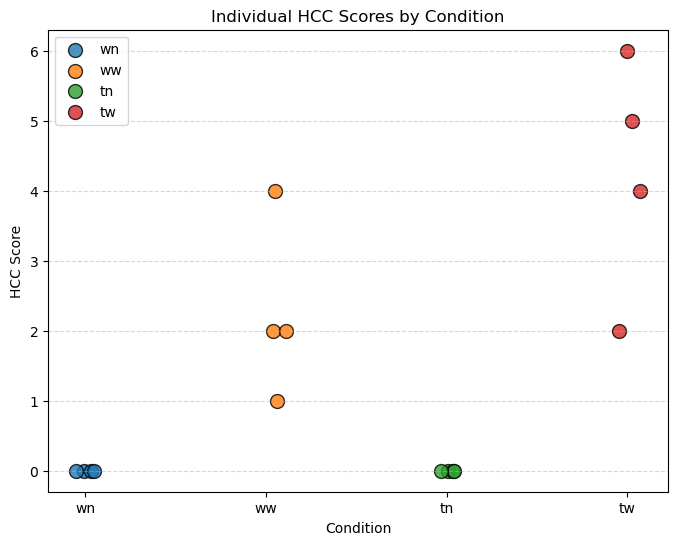

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

hcc_mapping = {
    'wn80': 0, 'wn81': 0, 'wn83': 0, 'wn84': 0,
    'ww95': 2, 'ww96': 1, 'ww99': 2, 'ww101': 4,
    'tn80': 0, 'tn82': 0, 'tn84': 0, 'tn85': 0,
    'tw99': 5, 'tw100': 4, 'tw102': 6, 'tw108': 2
}

df = pd.DataFrame(list(hcc_mapping.items()), columns=['Sample', 'HCC_Score'])
df['Condition'] = df['Sample'].str[:2]

conditions = df['Condition'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(8, 6))

for i, cond in enumerate(conditions):
    subset = df[df['Condition'] == cond]
    # Adding jitter to ensure individual points are visible
    jitter = np.random.normal(0, 0.05, size=len(subset))
    x_coords = [i] * len(subset) + jitter
    plt.scatter(x_coords, subset['HCC_Score'], color=colors[i], label=cond, s=100, alpha=0.8, edgecolors='k')

plt.xticks(range(len(conditions)), conditions)
plt.title('Individual HCC Scores by Condition')
plt.ylabel('HCC Score')
plt.xlabel('Condition')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
# plt.savefig('hcc_individual_points.png')

## Prepare/Process Mouse Liver Atlas Reference

In [7]:
base_path = "/pub/asdalvi/CHIP_liver/reference_data/"
counts_path = os.path.join(base_path, "rawData_mouseNafld/countTable_mouseNafld/")

In [8]:
matrix_path = os.path.join(counts_path, "matrix.mtx.gz")
matrix = scipy.io.mmread(matrix_path).T.tocsr() # need to tranpose

adata = sc.AnnData(matrix)

genes_path = os.path.join(counts_path, "features.tsv.gz")
genes = pd.read_csv(genes_path, header=None, sep='\t')


adata.var_names = genes[0].values
adata.var['gene_ids'] = genes[0].values

barcodes_path = os.path.join(counts_path, "barcodes.tsv.gz")
barcodes = pd.read_csv(barcodes_path, header=None, sep='\t')
adata.obs_names = barcodes[0].values

In [9]:
myeloid_csv = os.path.join(base_path, "annot_mouseNafldMyeloid.csv")
lymphoid_csv = os.path.join(base_path, "annot_mouseNafldLymphoid.csv")
meta_myeloid = pd.read_csv(myeloid_csv, index_col=None)
meta_lymphoid = pd.read_csv(lymphoid_csv, index_col=None)

all_labels = pd.concat([meta_myeloid, meta_lymphoid])

In [10]:
all_labels.index = all_labels['cell']

common_cells = adata.obs_names.intersection(all_labels.index)
print(f"Keeping {len(common_cells)} annotated cells out of {adata.n_obs} total")

adata = adata[common_cells].copy()
adata.obs = all_labels.loc[common_cells]

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

Keeping 64244 annotated cells out of 256345 total


## View the Reference Dataset Atlas UMAP

In [12]:
bdata = adata.copy()

In [13]:
bdata

AnnData object with n_obs × n_vars = 64244 × 31053
    obs: 'UMAP_1', 'UMAP_2', 'cluster', 'annot', 'sample', 'cell', 'digest', 'typeSample', 'diet'
    var: 'gene_ids'
    uns: 'log1p'

In [18]:
bdata.obs['annot'].value_counts().sort_values()

annot
Peritoneal macs           185
Naive CD4                 352
NKT                       488
Gd                        578
Teff memory               597
T helper                  640
Treg                      667
Mig cDCs                  994
Trans Monocytes 2        1046
NK                       1165
Naive CD8                1396
Pre-MoKC and MoKC        1512
ILCs                     1789
CTLs                     2099
Patrolling Monocytes     2332
CV and Capsule           2709
LAMs                     3029
cDC1s                    4018
Monocytes                4603
cDC2s                    4725
pDCs                     5351
B cells                  6200
KCs                      7734
Trans Monocytes 1       10035
Name: count, dtype: int64

In [53]:
celltype_to_count = {}
for c in set(bdata.obs['annot']):
    celltype_to_count[c] = 0

In [59]:
for index, row in bdata.obs.iterrows():
    celltype = row['annot']
    celltype_to_count[celltype] += 1

In [60]:
celltype_to_count

{'Monocytes': 9206,
 'B cells': 12400,
 'Peritoneal macs': 370,
 'T helper': 1280,
 'Treg': 1334,
 'Trans Monocytes 2': 2092,
 'Naive CD8': 2792,
 'CV and Capsule': 5418,
 'CTLs': 4198,
 'Mig cDCs': 1988,
 'Pre-MoKC and MoKC': 3024,
 'cDC1s': 8036,
 'ILCs': 3578,
 'Naive CD4': 704,
 'Trans Monocytes 1': 20070,
 'LAMs': 6058,
 'pDCs': 10702,
 'NK': 2330,
 'NKT': 976,
 'cDC2s': 9450,
 'KCs': 15468,
 'Gd': 1156,
 'Patrolling Monocytes': 4664,
 'Teff memory': 1194}

... storing 'annot' as categorical
... storing 'sample' as categorical
... storing 'digest' as categorical
... storing 'typeSample' as categorical
... storing 'diet' as categorical


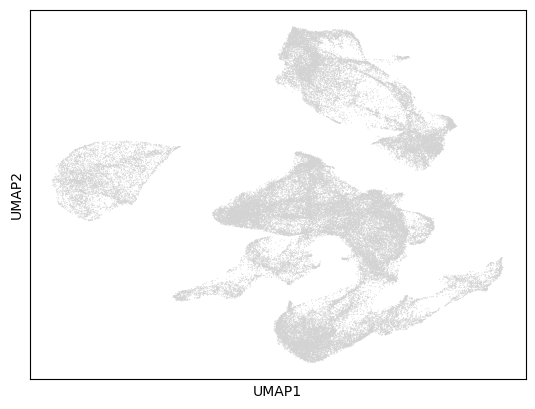

In [35]:
sc.pp.neighbors(bdata)
bdata.obsm['X_umap'] = bdata.obs[['UMAP_1', 'UMAP_2']].values

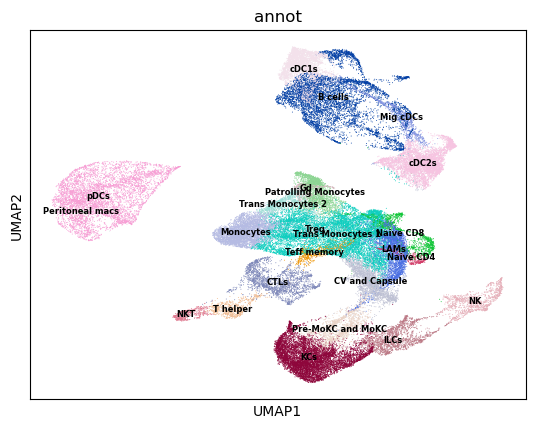

In [41]:
sc.pl.umap(bdata, color='annot', legend_loc='on data', legend_fontsize=6)

## Train and Evaluate the Model on Atlas

In [8]:
import scanpy as sc
import celltypist
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd


# Assume 'adata' is your full, clean, normalized Atlas
# We extract the labels to ensure we split them evenly (Stratification)
labels = adata.obs['annot'] # Make sure this matches your column name!

print("Splitting data 80% Train / 20% Test...")
# Stratify=labels ensures that rare cells (like Dendritic cells) end up in BOTH sets
# otherwise they might all end up in 'Test' and the model won't learn them.
train_indices, test_indices = train_test_split(
    adata.obs_names, 
    test_size=0.2, 
    random_state=42, 
    stratify=labels
)

# Create the two datasets: 80/20 TRAIN TEST SPLIT 
train_adata = adata[train_indices].copy()
test_adata = adata[test_indices].copy()

print(f"Training on {train_adata.n_obs} cells. Testing on {test_adata.n_obs} cells.")


model = celltypist.train(
    train_adata, 
    labels='annot', 
    n_jobs=8, 
    check_expression=False,
    use_SGD=False, # don't use SGD
    feature_selection=True # speed up training 
)


print("Predicting on Test set")
predictions = celltypist.annotate(
    test_adata, 
    model=model, 
    majority_voting=False # Turn OFF majority voting for raw accuracy check
)

# Extract the predicted labels
predicted_labels = predictions.predicted_labels['predicted_labels']
true_labels = test_adata.obs['annot']

print(classification_report(true_labels, predicted_labels))


# Calculate matrix
cm = confusion_matrix(true_labels, predicted_labels, labels=model.classifier.classes_)

# Plot
fig, ax = plt.subplots(figsize=(12, 12)) # Make it big to read labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classifier.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')

plt.title("CellTypist Model Evaluation (Confusion Matrix)")
plt.show()

Splitting data 80% Train / 20% Test...


🍳 Preparing data before training


Training on 51395 cells. Testing on 12849 cells.


✂️ 8823 non-expressed genes are filtered out
🔬 Input data has 51395 cells and 22230 genes
⚖️ Scaling input data
🏋️ Training data using SGD logistic regression
🔎 Selecting features
🧬 2310 features are selected
🏋️ Starting the second round of training
🏋️ Training data using logistic regression


KeyboardInterrupt: 

Generating ROC Curves...


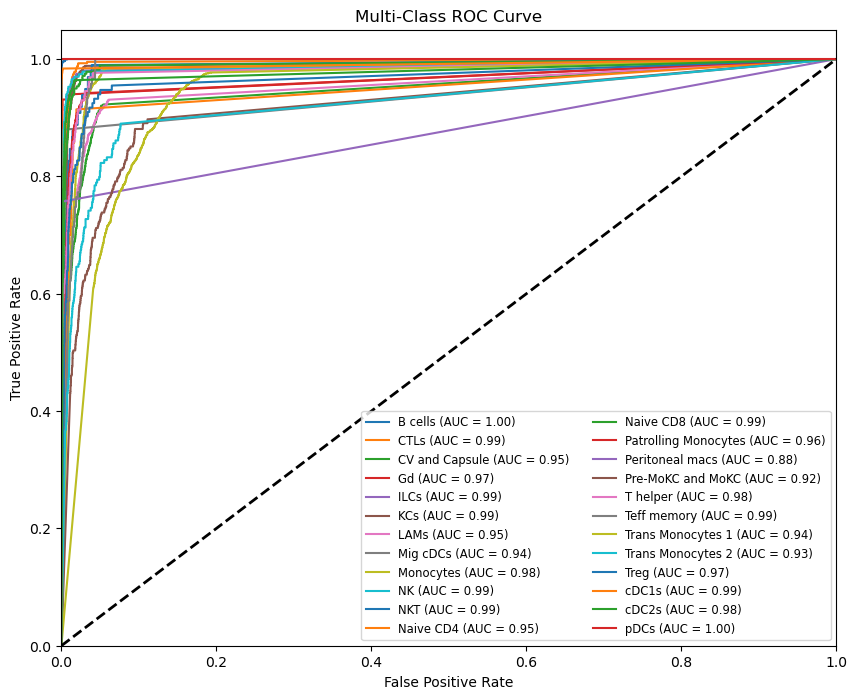

In [63]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ROC CURVES (One-vs-Rest) 
print("Generating ROC Curves...")

# Get the probabilities (Confidence scores)
# predictions.probability_matrix is a DataFrame where cols = cell types, rows = cells
y_score = predictions.probability_matrix
class_names = y_score.columns.tolist()

# Binarize the True Labels to match the probability columns
# This converts "Kupffer" into [0, 0, 1, 0...]
lb = LabelBinarizer()
lb.fit(class_names)
y_test_bin = lb.transform(test_adata.obs['annot'])

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i, class_name in enumerate(class_names):
    # Calculate ROC for this specific cell type vs all others
    # Note: We use y_score[class_name] to get the specific column
    fpr[class_name], tpr[class_name], _ = roc_curve(y_test_bin[:, i], y_score[class_name])
    roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

# Plot all ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

# Loop through and plot (You can limit this to top 10 if you have too many classes)
for class_name in class_names:
    ax.plot(
        fpr[class_name], 
        tpr[class_name], 
        label=f'{class_name} (AUC = {roc_auc[class_name]:.2f})'
    )

# Plot the "Random Guess" line
ax.plot([0, 1], [0, 1], 'k--', lw=2)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Multi-Class ROC Curve')
ax.legend(loc="lower right", fontsize='small', ncol=2) # ncol=2 helps if you have many classes

plt.show() # Or plt.savefig("roc_curves.png")

In [64]:
# SAVE THE MODEL 
# model.write("/pub/asdalvi/CHIP_liver/models/my_celltypist_liver_immune_model_v2.pkl")

## Run the Model on CHIP Dataset

In [4]:
data_dir = "/pub/asdalvi/CHIP_liver/data/male_6_month_mice_data/merged_sample_matrices"

adata = sc.read_mtx(os.path.join(data_dir, "matrix.mtx")).T
genes = pd.read_csv(os.path.join(data_dir, "features.tsv"), header=None)
barcodes = pd.read_csv(os.path.join(data_dir, "barcodes.tsv"), header=None)
meta = pd.read_csv(os.path.join(data_dir, "metadata.csv"), index_col=0)

adata.var_names = genes[0].values
adata.obs_names = barcodes[0].values
adata.obs = meta # this adds "orig.ident" (Mouse Sample ID)

### Some preprocessing first

In [5]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# sc.pl.violin(
#     adata, 
#     ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], 
#     jitter=0.4, 
#     multi_panel=True,
#     size=1 # adjusts dot size
# )

In [6]:
adata = adata[(adata.obs.n_genes_by_counts > 1000) & (adata.obs.n_genes_by_counts < 6000), :]

adata = adata[adata.obs.total_counts < 40000, :]

adata = adata[adata.obs.pct_counts_mt < 10, :]

adata.var_names_make_unique()

adata.layers['counts'] = adata.X.copy()

print("Normalizing")

# Normalize (Required for CellTypist AND UMAP)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

print("Computing umap")
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

Normalizing
Computing umap


2026-03-20 15:52:54.153706: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-20 15:52:54.817287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


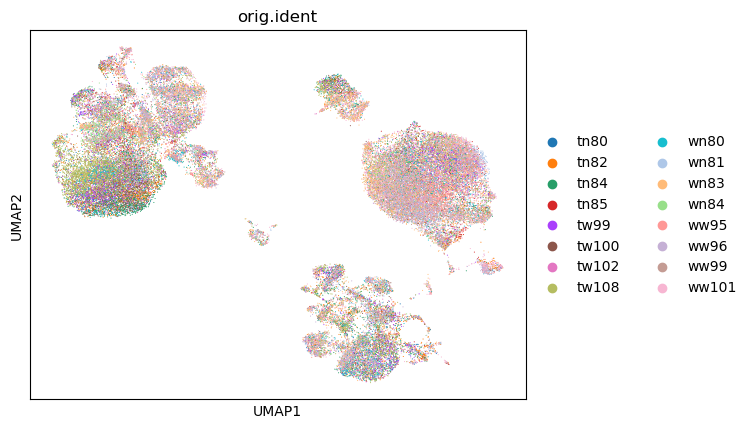

<Figure size 640x480 with 0 Axes>

In [8]:
sc.pl.umap(adata, color="orig.ident")
plt.savefig('/pub/asdalvi/CHIP_liver/figures/sample_colored_UMAP.png')

### Running our Celltypist model

In [59]:
#  Run CellTypist 
model = celltypist.models.Model.load("/pub/asdalvi/CHIP_liver/models/my_celltypist_liver_immune_model_v3.pkl") 

# Predict
# majority_voting=True allows the model to use the neighbors (which we just saw are good!)
# to smooth out any noise.
predictions = celltypist.annotate(adata, model=model, majority_voting=True)

2026-01-15 16:44:45 | [INFO] 🔬 Input data has 51386 cells and 32285 genes
2026-01-15 16:44:45 | [INFO] 🔗 Matching reference genes in the model
2026-01-15 16:44:46 | [INFO] 🧬 2187 features used for prediction
2026-01-15 16:44:46 | [INFO] ⚖️ Scaling input data
2026-01-15 16:44:48 | [INFO] 🖋️ Predicting labels
2026-01-15 16:44:48 | [INFO] ✅ Prediction done!
2026-01-15 16:44:48 | [INFO] 👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
2026-01-15 16:44:48 | [INFO] ⛓️ Over-clustering input data with resolution set to 20
2026-01-15 16:44:50 | [INFO] 🗳️ Majority voting the predictions
2026-01-15 16:44:50 | [INFO] ✅ Majority voting done!


In [61]:
predictions

CellTypist prediction result for 51386 query cells
    predicted_labels: data frame with 3 columns ('predicted_labels', 'over_clustering', 'majority_voting')
    decision_matrix: data frame with 51386 query cells and 24 cell types
    probability_matrix: data frame with 51386 query cells and 24 cell types
    adata: AnnData object referred

In [64]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,celltypist_pred,conf_score
tn80_AAACCATTCCCGCACT-1,tn80,11848,3633,3633,11848.0,137.0,1.156313,CTLs,0.999361
tn80_AAACCATTCCTGTCCA-1,tn80,11989,3323,3323,11989.0,137.0,1.142714,B cells,1.000000
tn80_AAACCATTCGATCCAA-1,tn80,10055,3068,3068,10055.0,59.0,0.586773,NK,0.928007
tn80_AAACCGCTCACCTCTG-1,tn80,27152,5440,5440,27152.0,303.0,1.115940,pDCs,1.000000
tn80_AAACCGCTCACTAGGC-1,tn80,13971,3868,3868,13971.0,176.0,1.259752,CTLs,0.999808
...,...,...,...,...,...,...,...,...,...
ww99_TGTCTCACAATACTCT-1,ww99,4613,2039,2039,4613.0,78.0,1.690874,Teff memory,0.995930
ww99_TGTCTCACAGCTCTGT-1,ww99,8019,3058,3058,8019.0,91.0,1.134805,Trans Monocytes 1,0.962004
ww99_TGTCTTGCAGGATACT-1,ww99,17239,4248,4248,17239.0,151.0,0.875921,Patrolling Monocytes,0.999557
ww99_TGTCTTGCATTACTCG-1,ww99,8399,2909,2909,8399.0,116.0,1.381117,CTLs,0.999585


(array([   77.,    83.,    69.,    66.,    97.,    87.,    95.,    94.,
           83.,    89.,   111.,   140.,   146.,   145.,   183.,   276.,
          326.,   489.,   880., 47850.]),
 array([0.00601821, 0.0557173 , 0.10541639, 0.15511548, 0.20481456,
        0.25451365, 0.30421274, 0.35391183, 0.40361092, 0.45331001,
        0.5030091 , 0.55270819, 0.60240728, 0.65210637, 0.70180546,
        0.75150455, 0.80120364, 0.85090273, 0.90060182, 0.95030091,
        1.        ]),
 <BarContainer object of 20 artists>)

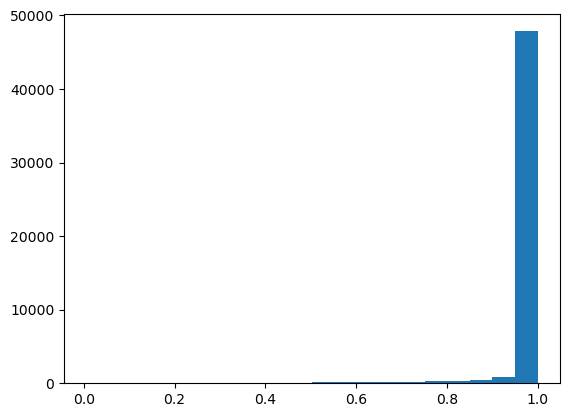

In [12]:
# plt.hist(predictions.probability_matrix.max(axis=1), bins=20)

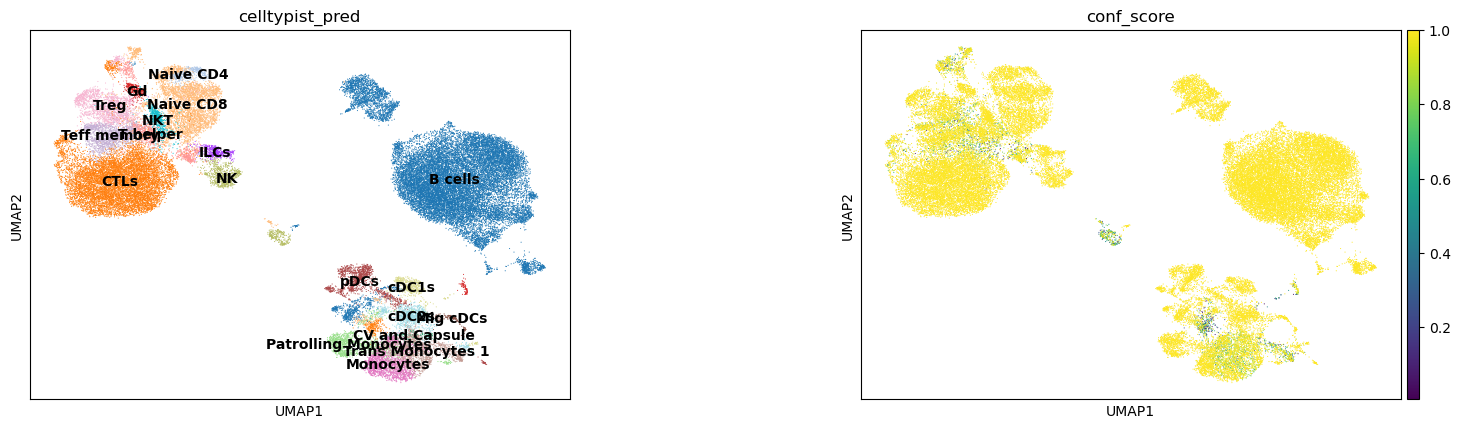

In [63]:
adata.obs['celltypist_pred'] = predictions.predicted_labels['majority_voting']
# adata.obs['celltypist_pred'] = predictions.predicted_labels['predicted_labels']

# calculate confidence score Manually
# We take the maximum value from the probability matrix for each cell
adata.obs['conf_score'] = predictions.probability_matrix.max(axis=1).values

# Visualization
sc.pl.umap(
    adata, 
    color=['celltypist_pred', 'conf_score'], 
    wspace=0.4,
    legend_loc='on data' # Helps if you have many labels
)

In [6]:
# add HCC score and also the sample condition info before we write it to disk 
# add hcc score to adata
hcc_mapping = {
    'wn80': 0, 'wn81': 0, 'wn83': 0, 'wn84': 0,
    'ww95': 2, 'ww96': 1, 'ww99': 2, 'ww101': 4,
    'tn80': 0, 'tn82': 0, 'tn84': 0, 'tn85': 0,
    'tw99': 5, 'tw100': 4, 'tw102': 6, 'tw108': 2
}

# map condition abbreviaton to full name
condition_to_full = {
    'tn': 'tet2_normal',
    'tw': 'tet2_western',
    'wn': 'wildtype_normal',
    'ww': 'wildtype_western'
}


adata.obs['condition'] = adata.obs['orig.ident'].map(lambda x: x[:2])
adata.obs['HCC_score'] = adata.obs['orig.ident'].map(hcc_mapping)
adata.obs['condition_full'] = adata.obs['orig.ident'].map(lambda x: condition_to_full[x[:2]])

In [9]:
# import anndata as ad 

# # save processed data
adata.write_h5ad("/pub/asdalvi/CHIP_liver/male_6_month_mice_data/processed_merged_adata/preprocessed_male_6_month_adata.h5ad")

... storing 'condition' as categorical
... storing 'condition_full' as categorical


In [31]:
# adata.obs['celltypist_pred'].value_counts()

## Comparing our Predictions to Noemie's Manual Annotations

In [22]:
noemie_data_path = "/pub/asdalvi/CHIP_liver/export_mtx"

matrix_path = os.path.join(noemie_data_path, "matrix.mtx")
matrix = scipy.io.mmread(matrix_path).T.tocsr() # need to tranpose

noemie_adata = sc.AnnData(matrix)

In [27]:
genes_path = os.path.join(noemie_data_path, "features.tsv")

genes = pd.read_csv(genes_path)
genes['gene_name'] = genes['x'].map(lambda x: x.split("\t")[1])

noemie_adata.var_names = genes['gene_name'].values
noemie_adata.var['gene_ids'] = genes['gene_name'].values

barcodes_path = os.path.join(noemie_data_path, "barcodes.tsv")
barcodes = pd.read_csv(barcodes_path)

barcodes['cell_id'] = barcodes['x'].map(lambda x: x.split("\t")[1])

noemie_adata.obs_names = barcodes['cell_id'].values

annotation_csv_path = os.path.join(noemie_data_path, "cell_annotations.csv")
annotations_csv = pd.read_csv(annotation_csv_path, index_col=0)

# get all cells with annotations in adata
common_cells_noemie = noemie_adata.obs_names.intersection(annotations_csv.index)

noemie_adata.obs = annotations_csv.loc[common_cells_noemie]

# only get 6 month male mice for accurate comparison to our predictions 
noemie_male_6_month = noemie_adata[(noemie_adata.obs['gender'] == 'male') & (noemie_adata.obs['age'] == '6 months')]

In [30]:
import pandas as pd
import re

def standardize_index_robust(adata_obj, sample_col):
    """
    Standardizes the index to 'SampleName_Barcode' format.
    Uses .values to prevent pandas index alignment errors.
    """
    # robustly extract the DNA part (10+ A/C/G/T)
    # .astype(str) ensures we don't crash on non-string types
    # .values ensures we get a raw array, not a pandas Series with an index
    raw_index = adata_obj.obs_names.to_series().astype(str).values
    
    # We use a regex to pull the barcode out of the existing index string
    # This works on 'Barcode-1', 'Sample_Barcode', etc. (Idempotent)
    dna_part = pd.Series(raw_index).str.extract(r'([ACGT]{10,})')[0].values
    
    sample_part = adata_obj.obs[sample_col].astype(str).values
    
    # Reconstruct: Sample_DNA
    # We assign directly to obs_names using the constructed list
    new_names = [f"{s}_{d}" for s, d in zip(sample_part, dna_part)]
    
    adata_obj.obs_names = new_names
    print(f"Updated index for {len(new_names)} cells using column '{sample_col}'")


adata = sc.read_h5ad("/pub/asdalvi/CHIP_liver/male_6_month_mice_data/processed_merged_adata/preprocessed_male_6_month_adata.h5ad")


# Fix YOUR Data (adata) using 'orig.ident' (e.g., tn80)
# (Based on your screenshot showing 'orig.ident' column)
print("Standardizing Your Data...")
standardize_index_robust(adata, sample_col='orig.ident')

# Fix NOEMIE'S Data (noemie_male_6_month) using 'sample' (e.g., wn80)
# (Based on your screenshot showing 'sample' column)
print("Standardizing Noemie's Data...")
standardize_index_robust(noemie_male_6_month, sample_col='sample')

common_cells = noemie_male_6_month.obs_names.intersection(adata.obs_names)

print(f"Found {len(common_cells)} overlapping cells.")

Standardizing Your Data...
Updated index for 51386 cells using column 'orig.ident'
Standardizing Noemie's Data...
Updated index for 52601 cells using column 'sample'
Found 51379 overlapping cells.


In [65]:
print(noemie_male_6_month.obs['cluster'].value_counts())
print("\n")
print(adata.obs['celltypist_pred'].value_counts())

cluster
B cells                    19442
T CD8+ effector            11020
Naive T cells               4012
MonoDC                      3699
T CD4+                      2267
11                          2102
NKT cells                   2005
cDC2                        1627
pDC                         1197
NK cells                    1111
10                          1077
non classical monocytes      989
cDC                          627
cycling cells                510
basophils                    318
pré-DC                       204
endothelial cells            150
plasma cells                  83
macrophages                   82
cycling cDC                   33
cDC1                          24
Pre-neutrophils               17
20                             4
22                             1
Name: count, dtype: int64


celltypist_pred
B cells                 22045
CTLs                     9835
Naive CD8                3978
Treg                     1842
Monocytes                1780
Teff m

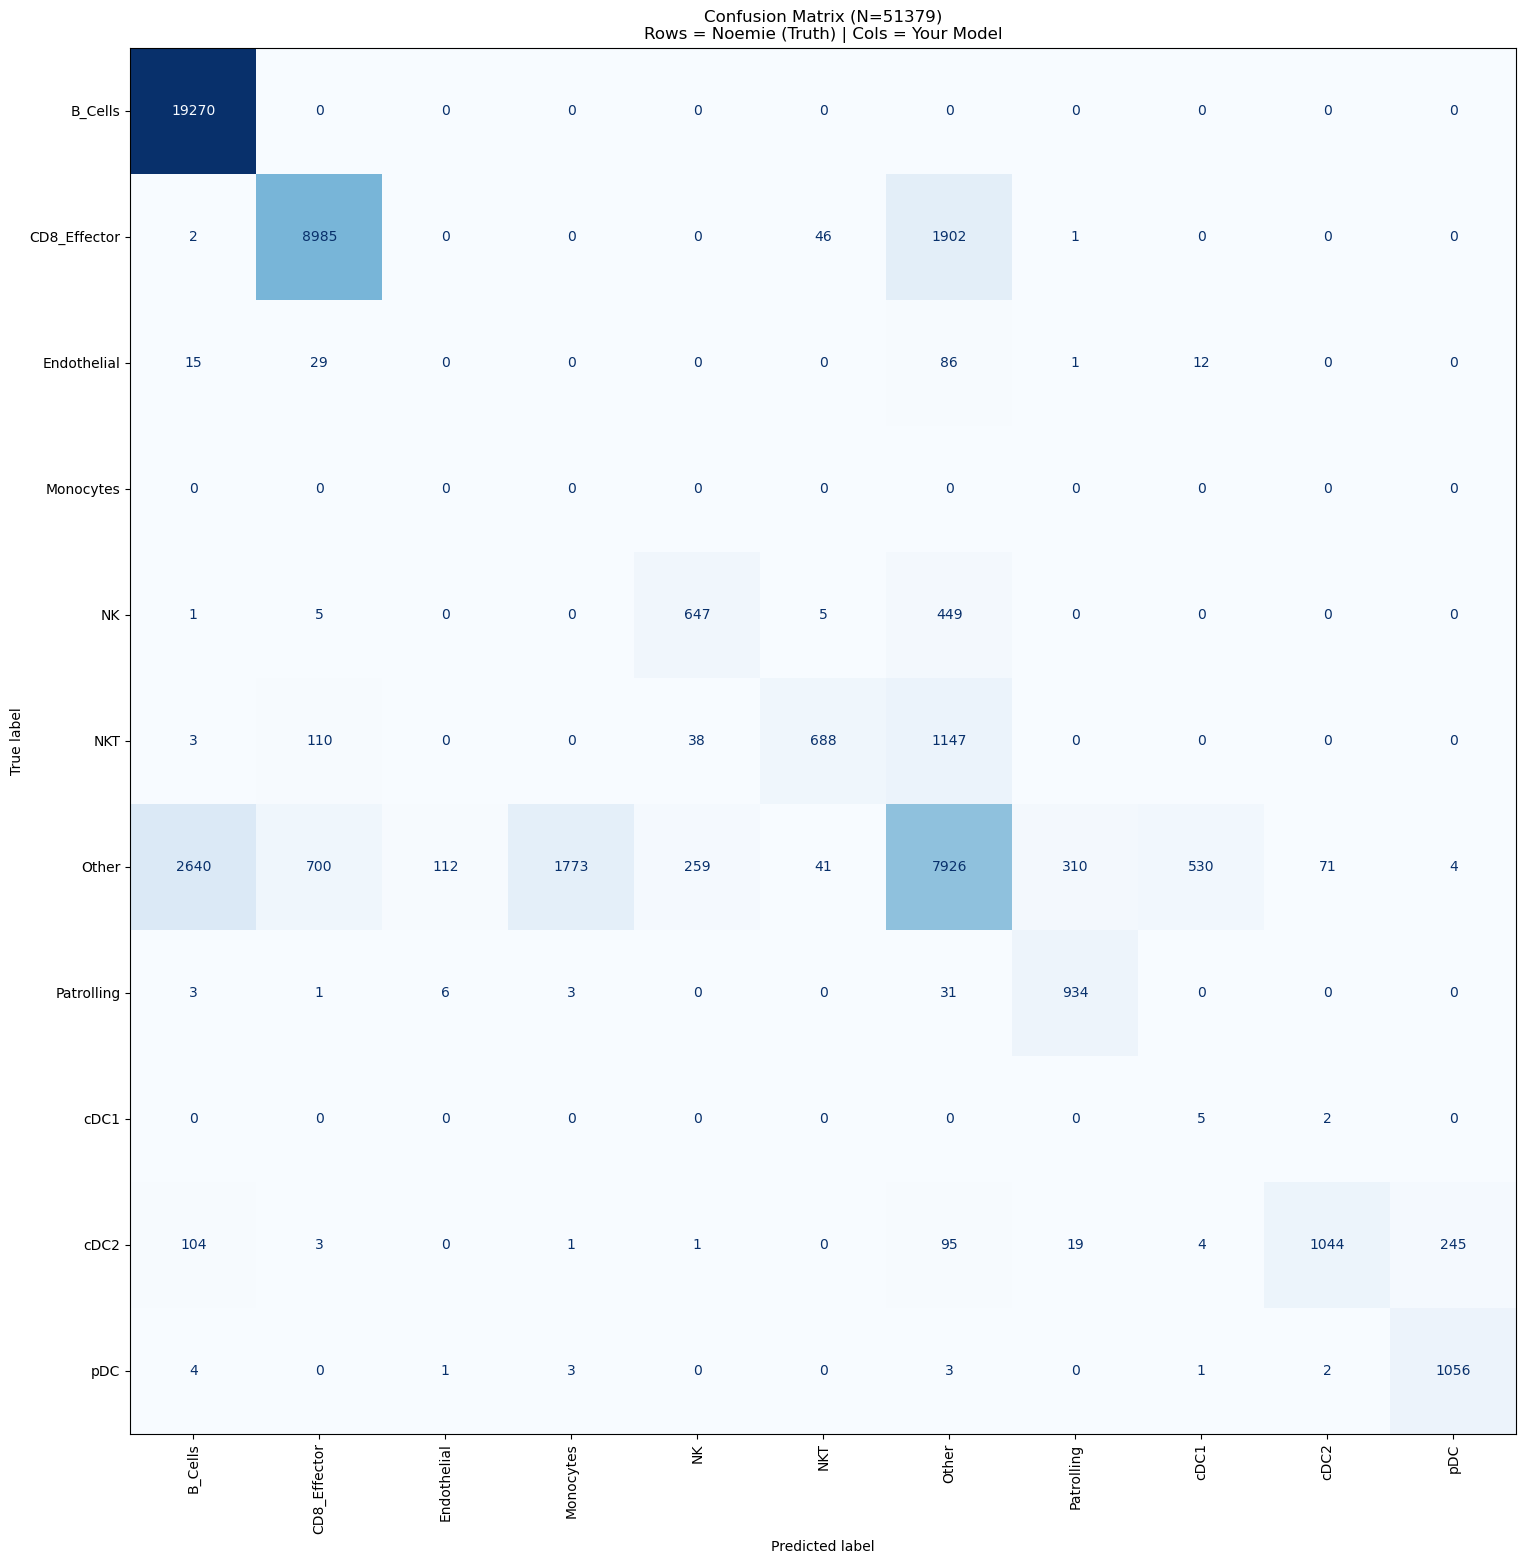

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Subset Noemie's object by only keeping cell barcodes in both datasets
final_comparison = noemie_male_6_month[common_cells].copy()

# Transfer your model's predictions into this container
final_comparison.obs['celltypist_pred'] = adata.obs.loc[common_cells, 'celltypist_pred']


# Map Noemie's Labels (Rows)
noemie_map = {
    # Direct Matches
    'B cells': 'B_Cells',
    'NK cells': 'NK',
    'NKT cells': 'NKT',
    
    # High-Confidence Synonyms only
    'monocytes': 'Monocytes',                # Classical Ly6C+
    'non classical monocytes': 'Patrolling', # Non-classical Ly6C-
    'T CD8+ effector': 'CD8_Effector',       # Matches CTLs
    
    # Dendritic Cells (Clear subsets)
    'cDC1': 'cDC1',
    'cDC2': 'cDC2',
    'pDC': 'pDC',
    
    # Structural
    'endothelial cells': 'Endothelial',
    
    # DONT MAP plasma cells, naive T (ambiguous could be CD4 or CD8), T CD4+, or macrophages
}

# Map Labels (Columns)
my_map = {
    # Direct Matches
    'B cells': 'B_Cells',
    'NK': 'NK',
    'NKT': 'NKT',
    
    'Monocytes': 'Monocytes',                # Classical
    'Patrolling Monocytes': 'Patrolling',    # Non-classical
    'CTLs': 'CD8_Effector',                  # Cytotoxic = Effector
    
    # Dendritic Cells
    'cDC1s': 'cDC1',
    'cDC2s': 'cDC2',
    'pDCs': 'pDC',
    
    # structural
    'CV and Capsule': 'Endothelial',
    
    # Strict Macrophage Mapping
    # map KCs/LAMs to Macrophages but we DO NOT map Trans Monocytes
    # This means Trans Monos will NOT match Noemie's Macrophages (as desired)
    'KCs': 'Macrophages_Resident',
    'LAMs': 'Macrophages_Resident', 
}

# add to one dataframe 
final_comparison.obs['meta_truth'] = final_comparison.obs['cluster'].astype(str).map(noemie_map).fillna('Other')
final_comparison.obs['meta_pred'] = final_comparison.obs['celltypist_pred'].astype(str).map(my_map).fillna('Other')

# create matrix
labels = sorted(list(set(final_comparison.obs['meta_truth'].unique()) | set(final_comparison.obs['meta_pred'].unique())))
cm = confusion_matrix(final_comparison.obs['meta_truth'], final_comparison.obs['meta_pred'], labels=labels)

# Plot
fig, ax = plt.subplots(figsize=(18, 18))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical', values_format='d', colorbar=False)

plt.title(f"Confusion Matrix (N={len(common_cells)})\nRows = Noemie (Truth) | Cols = Your Model")
plt.show()

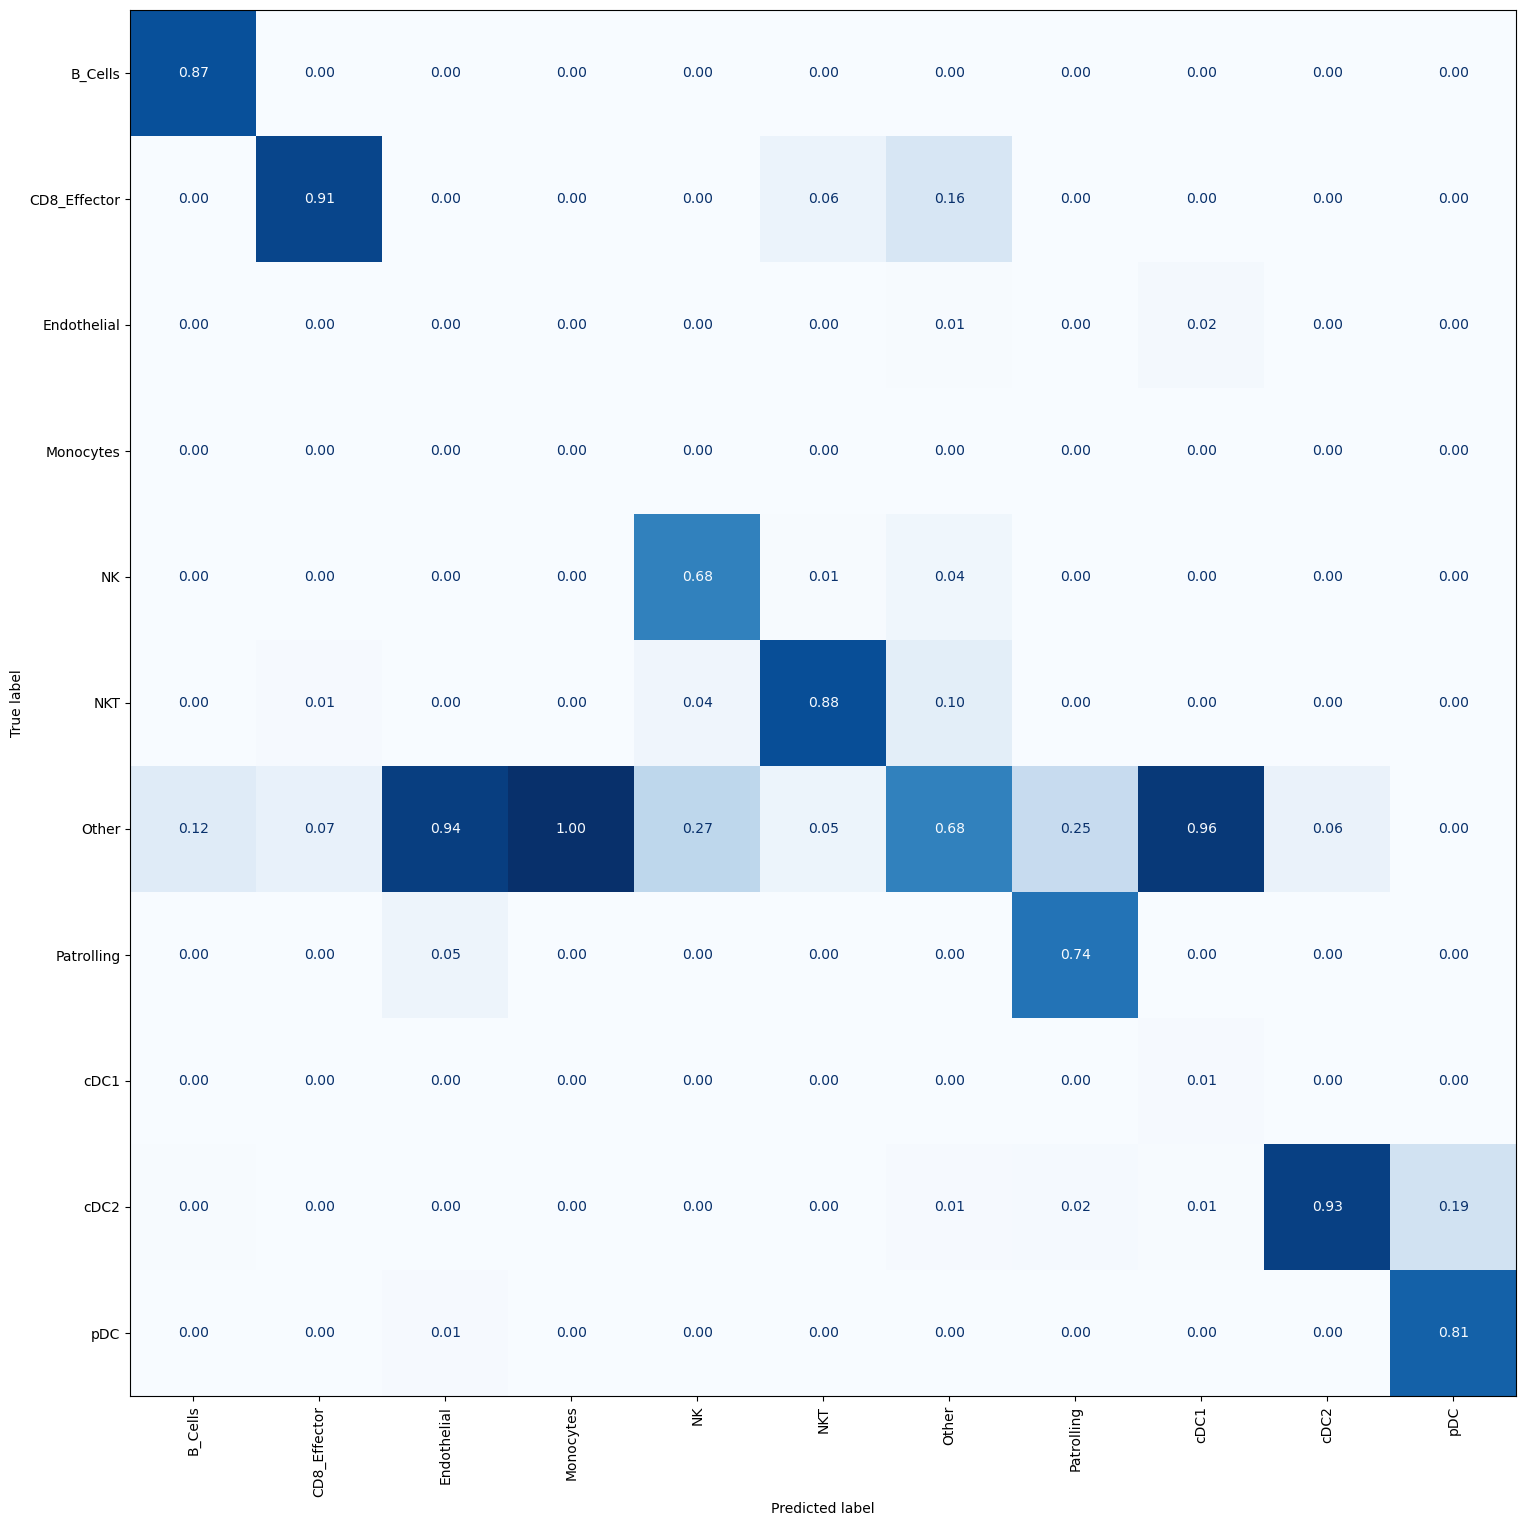

In [38]:
cm_float = cm.astype('float')

fig, ax = plt.subplots(figsize=(18, 18))

# Row Normalization (Sensitivity/Recall perspective)
# "Of everything Dataset A called 'X', what did Dataset B call it?"
row_sums = cm_float.sum(axis=1, keepdims=True)
cm_row = np.divide(cm_float, row_sums, out=np.zeros_like(cm_float), where=row_sums!=0)

disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_col, display_labels=labels)
disp2.plot(ax=ax, cmap='Blues', xticks_rotation='vertical', values_format='.2f', colorbar=False)

#### AUROC Plot between My and Noemie's Cell Annotations

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Ensure cm is a float array for division
cm_float = cm.astype('float')

# 1. Row Normalization (Sensitivity/Recall perspective)
# "Of everything Dataset A called 'X', what did Dataset B call it?"
row_sums = cm_float.sum(axis=1, keepdims=True)
cm_row = np.divide(cm_float, row_sums, out=np.zeros_like(cm_float), where=row_sums!=0)

# 2. Column Normalization (Precision perspective)
# "Of everything Dataset B called 'Y', what did Dataset A call it?"
col_sums = cm_float.sum(axis=0, keepdims=True)
cm_col = np.divide(cm_float, col_sums, out=np.zeros_like(cm_float), where=col_sums!=0)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

# Plot Row Normalized
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_row, display_labels=labels)
disp1.plot(ax=ax1, cmap='Blues', xticks_rotation='vertical', values_format='.2f', colorbar=False)
ax1.set_title("Normalized by Rows (Noemie's Labels)\n'What % of Noemie's X were found by my model?'")

# Plot Column Normalized
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_col, display_labels=labels)
disp2.plot(ax=ax2, cmap='Blues', xticks_rotation='vertical', values_format='.2f', colorbar=False)
ax2.set_title("Normalized by Columns (Your Model's Labels)\n'What % of my model's Y are actually Noemie's X?'")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

Aligned 51379 cells for ROC analysis.


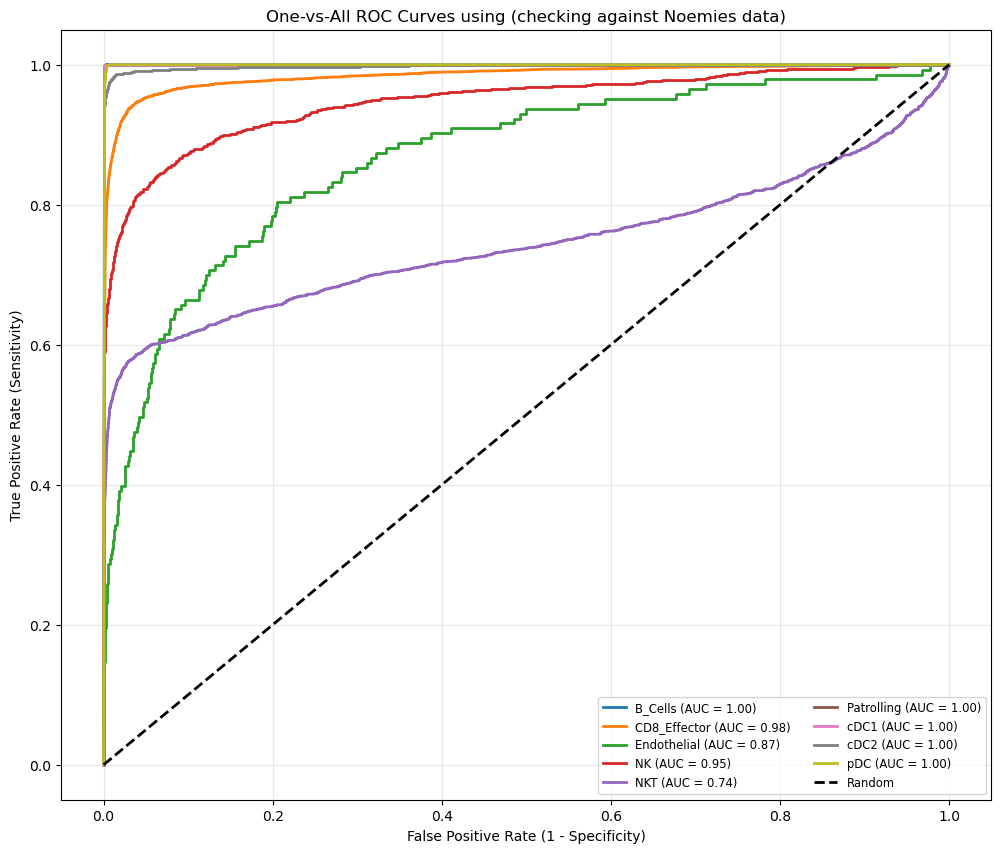

In [71]:
mapped_scores = pd.DataFrame(index=raw_probs.index)
unique_targets = set(my_map.values())

for target in unique_targets:
    source_cols = [k for k, v in my_map.items() if v == target]
    valid_cols = [col for col in source_cols if col in raw_probs.columns]
    
    if valid_cols:
        mapped_scores[target] = raw_probs[valid_cols].sum(axis=1)

# prepare truth labels using noemie's clustering 
# Map Noemie's clusters. Anything not in the map becomes NaN.
y_true_labels = final_comparison.obs['cluster'].astype(str).map(noemie_map)

# only use cell ids in our predictions  and noemie's data
# We force both objects to have the exact same index based on intersection
common_idx = mapped_scores.index.intersection(y_true_labels.index)
print(f"Aligned {len(common_idx)} cells for ROC analysis.")

# Subset both to the common index so they are identical in length and order
aligned_scores = mapped_scores.loc[common_idx]
aligned_truth = y_true_labels.loc[common_idx]

# Plot ROC Curves 
plt.figure(figsize=(12, 10))

for label in sorted(list(unique_targets)):
    if label in aligned_scores.columns:
        # Get aligned score vector
        scores = aligned_scores[label]
        
        # Valid mask using the ALIGNED truth
        # (Ignore cells that map to 'NaN' in the strict map - e.g. "Unknown 11")
        mask = aligned_truth.notna()
        
        if mask.sum() > 0:
            # Create Binary Truth (1 vs All) using ALIGNED data
            # We apply the mask to both truth and scores so they stay same length
            binary_truth = (aligned_truth[mask] == label).astype(int)
            subset_scores = scores[mask]
            
            # Check if we have at least one positive and one negative example
            if binary_truth.nunique() > 1:
                fpr, tpr, _ = roc_curve(binary_truth, subset_scores)
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('One-vs-All ROC Curves using (checking against Noemies data)')
plt.legend(loc="lower right", fontsize='small', ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

## Correlate Cell Type Proportions (Ex: Tex) with HCC Scores

In [3]:
adata = sc.read_h5ad("/pub/asdalvi/CHIP_liver/male_6_month_mice_data/processed_merged_adata/preprocessed_male_6_month_adata.h5ad")

In [11]:
adata.obs.to_csv("/pub/asdalvi/CHIP_liver/male_6_month_mice_data/processed_merged_adata/preprocessed_male_6_month_metadata.csv")
adata.var.to_csv("/pub/asdalvi/CHIP_liver/male_6_month_mice_data/processed_merged_adata/preprocessed_male_6_month_genes.csv")
# Save the matrix as a Matrix Market format (standard for Seurat)
from scipy.io import mmwrite
mmwrite("/pub/asdalvi/CHIP_liver/male_6_month_mice_data/processed_merged_adata/preprocessed_male_6_month_matrix.mtx", adata.X.T)

In [10]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,celltypist_pred,conf_score,condition,HCC_score,condition_full
tn80_AAACCATTCCCGCACT-1,tn80,11848,3633,3633,11848.0,137.0,1.156313,CTLs,0.999361,tn,0,tet2_normal
tn80_AAACCATTCCTGTCCA-1,tn80,11989,3323,3323,11989.0,137.0,1.142714,B cells,1.000000,tn,0,tet2_normal
tn80_AAACCATTCGATCCAA-1,tn80,10055,3068,3068,10055.0,59.0,0.586773,NK,0.928007,tn,0,tet2_normal
tn80_AAACCGCTCACCTCTG-1,tn80,27152,5440,5440,27152.0,303.0,1.115940,pDCs,1.000000,tn,0,tet2_normal
tn80_AAACCGCTCACTAGGC-1,tn80,13971,3868,3868,13971.0,176.0,1.259752,CTLs,0.999808,tn,0,tet2_normal
...,...,...,...,...,...,...,...,...,...,...,...,...
ww99_TGTCTCACAATACTCT-1,ww99,4613,2039,2039,4613.0,78.0,1.690874,Teff memory,0.995930,ww,2,wildtype_western
ww99_TGTCTCACAGCTCTGT-1,ww99,8019,3058,3058,8019.0,91.0,1.134805,Trans Monocytes 1,0.962004,ww,2,wildtype_western
ww99_TGTCTTGCAGGATACT-1,ww99,17239,4248,4248,17239.0,151.0,0.875921,Patrolling Monocytes,0.999557,ww,2,wildtype_western
ww99_TGTCTTGCATTACTCG-1,ww99,8399,2909,2909,8399.0,116.0,1.381117,CTLs,0.999585,ww,2,wildtype_western


In [9]:
adata.obs['celltypist_pred'].value_counts()

celltypist_pred
B cells                 22045
CTLs                     9835
Naive CD8                3978
Treg                     1842
Monocytes                1780
Teff memory              1665
Trans Monocytes 1        1616
pDCs                     1305
Patrolling Monocytes     1265
T helper                 1143
cDC2s                    1119
NK                        945
NKT                       780
cDC1s                     552
ILCs                      435
Gd                        400
Naive CD4                 367
Mig cDCs                  195
CV and Capsule            119
Name: count, dtype: int64

## Compute GSEA Scores for all Cells (AUCell and ssGSEA)

In [2]:
import decoupler as dc
import pydeseq2.dds
import pydeseq2.ds
import pandas as pd
import scanpy as sc
import gseapy as gp
import pandas as pd
import numpy as np
from pyscenic.aucell import aucell, create_rankings
from ctxcore.genesig import GeneSignature 

In [3]:
def load_gmt(gmt_path):
    """
    Returns all gene sets at the gmt path
    """
    gene_sets = {}
    with open(gmt_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) > 2:
                # Key is index 0, Genes start at index 2 (index 1 is description)
                gene_sets[parts[1]] = parts[2:]
    return gene_sets

def capitalize_gene_set(gene_set):
    """
    Takes gene set with gene names in all caps ex: CCL3
    and converts them to capitalized form ex: Ccl3 
    """
    return  [gene.capitalize() for gene in gene_set]

def filter_high_scoring_cells(adata, GSEA_score_col_name, threshold):
    """
    Only retains cells with a high score for the gene set
    using a specified threshold. 
    """
    filtered_adata = adata[adata.obs[GSEA_score_col_name] >= threshold]
    return filtered_adata

In [7]:
# test = pd.read_csv('/pub/asdalvi/CHIP_liver/male_6_month_mice_data/GSEA_score_results/ssGSEA_scores/TEST_ssGSEA_CV_and_Capsule_bader_scores.csv')
# test.head(10)

## Subcluster CTLs 

In [6]:
CTL_adata = adata[adata.obs['celltypist_pred'] == 'CTLs']

In [9]:
import scanpy as sc


sc.pp.highly_variable_genes(CTL_adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.tl.pca(CTL_adata, svd_solver='arpack')
sc.pp.neighbors(CTL_adata, n_neighbors=10, n_pcs=20)
sc.tl.leiden(CTL_adata, key_added='ctl_sub')
sc.tl.umap(CTL_adata)

2026-02-28 00:29:08.660373: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-28 00:29:09.494716: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-28 00:29:12.685548: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


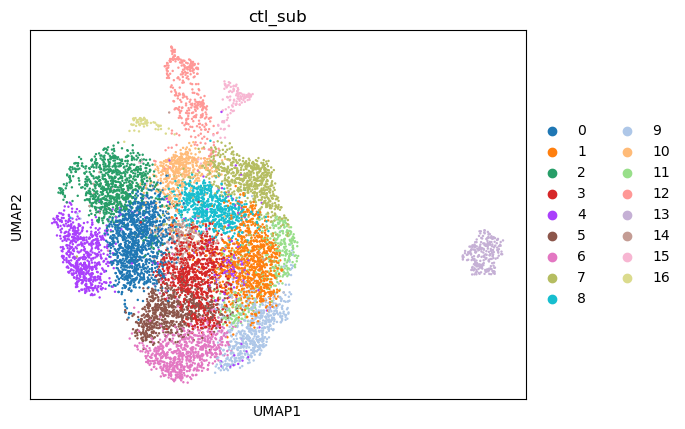

In [10]:
sc.pl.umap(CTL_adata, color=['ctl_sub'])